### 0. Imports and Global Configuration

This section imports all necessary libraries and sets up global parameters like the number of kernels, number of runs, results directory, and the paper's reported accuracy for various datasets.

In [1]:
!pip install aeon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 31.2 MB/s eta 0:00:00


In [2]:
# ── Standard library ──────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings("ignore")

# ── Numerics ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── aeon ──────────────────────────────────────────────────────────────────
from aeon.datasets import load_classification
from aeon.classification.convolution_based import (
    RocketClassifier,
    MiniRocketClassifier,
)
from aeon.transformations.collection.convolution_based import Rocket

# ── scikit-learn ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ── XGBoost (optional) ───────────────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[WARNING] xgboost not installed – Method C skipped.\n"
          "          pip install xgboost")

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# =============================================================================
# 0. GLOBAL CONFIGURATION
# =============================================================================

NUM_KERNELS  = 10_000   # paper default
N_RUNS       = 10       # matches paper's 10-run mean reporting protocol

# Save directly to a folder in your Google Drive
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Human-readable method names for the output table
METHOD_LABELS = {
    "A": "A: ROCKET+Ridge (baseline)",
    "B": "B: ROCKET+RF (head ablation)",
    "C": "C: ROCKET+XGBoost (head ablation)",
    "D": "D: MiniROCKET (efficiency)",
    "E": "E: ROCKET ppv-only (feature ablation)",
    "F": "F: ROCKET max-only (feature ablation)",
    # novel pooling operators — Improvement 1
    "G": "G: ROCKET ppp-only (novel pooling)",   # Changed MPV to PPP
    "H": "H: ROCKET pam-only (novel pooling)",
    "I": "I: ROCKET all-features (novel pooling)",
    # adaptive kernel count — Improvement 2
    "J": "J: ROCKET adaptive-k (efficiency)",
}

METHODS = list(METHOD_LABELS.keys())
SEEDS   = list(range(N_RUNS))         # [0 .. N_RUNS-1]

# Paper's reported accuracy from Appendix D, Table 1 (bake-off datasets)
# and Appendix E, Table 2 (additional 2018 datasets).
# Source: Dempster et al. 2020, arXiv:1910.13051.
# Development datasets (used during ROCKET's design) are marked with *.
# These values are the direct comparison targets for Method A reproduction.
PAPER_ACCURACY = {
    # ── Original 7 datasets from initial submission ───────────────────────
    "GunPoint":                         1.0000,   # Table 1
    "ItalyPowerDemand":                 0.9691,   # Table 1 (*development)
    "Coffee":                           1.0000,   # Table 1
    "Wine":                             0.8074,   # Table 1
    "ECG200":                           0.9060,   # Table 1
    "ArrowHead":                        0.8051,   # Table 1
    "Chinatown":                        0.9802,   # Table 2 (2018 datasets)

    # ── Added to improve reproduction coverage ────────────────────────────
    # Scalability stress-test: longest series in bake-off (l=2709)
    "HandOutlines":                     0.9416,   # Table 1
    # Scalability stress-test: largest training set in bake-off (n=8926)
    "ElectricDevices":                  0.7305,   # Table 1
    # Domain diversity: morphology/medical
    "Adiac":                            0.7847,   # Table 1
    "Beef":                             0.8333,   # Table 1 (*development)
    "ChlorineConcentration":            0.8130,   # Table 1
    "DistalPhalanxOutlineAgeGroup":     0.7547,   # Table 1
    # Domain diversity: motion/gesture
    "FaceFour":                         0.9750,   # Table 1
    # Domain diversity: NLP/symbolic
    "FiftyWords":                       0.8305,   # Table 1 (*development)
    # Domain diversity: biology
    "Fish":                             0.9789,   # Table 1 (*development)
    # Domain diversity: engineering/sensor
    "FordA":                            0.9449,   # Table 1 (*development)
    # Domain diversity: ecology
    "Herring":                          0.6859,   # Table 1 (*development)
    # Domain diversity: household devices
    "LargeKitchenAppliances":           0.9000,   # Table 1 (*development)
    # Domain diversity: meteorology
    "Lightning2":                       0.7639,   # Table 1
    # Domain diversity: environmental sensor
    "MoteStrain":                       0.9142,   # Table 1
    # Control dataset: near-perfect classifier, sanity check
    "Plane":                            1.0000,   # Table 1 (*development)
    # Domain diversity: botany/spectroscopy
    "SwedishLeaf":                      0.9659,   # Table 1 (*development)
    # Domain diversity: shape recognition
    "Symbols":                          0.9746,   # Table 1
}

# ── Full experiment datasets (all methods A–J, 10 seeds) ──────────────────
# These are small-to-medium and will complete in reasonable time
DATASETS = [
    "GunPoint", "ItalyPowerDemand", "Coffee", "Wine", "ECG200",
    "ArrowHead", "Chinatown", "Adiac", "Beef", "ChlorineConcentration",
    "DistalPhalanxOutlineAgeGroup", "FaceFour", "FiftyWords", "Fish",
    "Herring", "LargeKitchenAppliances", "Lightning2", "MoteStrain",
    "Plane", "SwedishLeaf", "Symbols",
]

# ── Scalability-only datasets (Method A baseline ONLY, 3 seeds) ───────────
# HandOutlines (length=2709) and ElectricDevices (n=8926) are used purely
# to verify the paper's scalability claims — too slow for full ablation.
SCALABILITY_DATASETS = [
    "HandOutlines",
    "ElectricDevices",
]

### 1. Helper: `load_dataset`

This function loads a specified time series classification dataset using `aeon.datasets.load_classification`.

In [3]:
# 1. HELPER: LOAD DATASET

def load_dataset(name: str):
    """
    Returns (X_train, y_train, X_test, y_test).
    aeon format: X has shape (n_cases, n_channels, n_timepoints).
    """
    print(f"  Loading {name} ...", end=" ", flush=True)
    X_train, y_train = load_classification(name, split="train")
    X_test,  y_test  = load_classification(name, split="test")
    print(f"train={X_train.shape[0]}, test={X_test.shape[0]}, "
          f"len={X_train.shape[-1]}")
    return X_train, y_train, X_test, y_test


### 2. Helpers: Custom ROCKET Transforms

These functions apply the ROCKET transform and extract specific features for ablation studies and the novel pooling operator experiments (Methods G/H/I). `rocket_transform` returns scaled features for the standard methods. `rocket_transform_raw` returns unscaled features so MPV and PAM can be computed before normalisation.

In [4]:
# 2. HELPERS: CUSTOM ROCKET TRANSFORMS (for ablations)

def rocket_transform(X_train, X_test, num_kernels=NUM_KERNELS, seed=0):
    """
    Applies Rocket transform and returns (X_train_feats, X_test_feats).
    Output shape: (n, 2*num_kernels) – full ppv+max features.
    StandardScaler is applied since Ridge, RF, and XGBoost all benefit from it.
    """
    transformer = Rocket(n_kernels=num_kernels, random_state=seed)
    X_tr = transformer.fit_transform(X_train)
    X_te = transformer.transform(X_test)

    # Normalise the transformed features
    scaler = StandardScaler(with_mean=True)
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)
    return X_tr, X_te, transformer


def rocket_transform_raw(X_train, X_test, num_kernels=NUM_KERNELS, seed=0):
    """
    Like rocket_transform but returns UNscaled features (no StandardScaler).
    Needed for novel pooling operators (G/H/I) because MPV and PAM have to be
    computed from the raw ppv/max values before any normalisation — otherwise
    the column relationships that define MPV and PAM are destroyed by scaling.
    Callers are responsible for scaling their own extracted columns.
    """
    transformer = Rocket(n_kernels=num_kernels, random_state=seed)
    X_tr_raw = transformer.fit_transform(X_train)
    X_te_raw = transformer.transform(X_test)
    return X_tr_raw, X_te_raw


def ppv_only(feature_matrix):
    """Return only the PPV columns (even-indexed) from ROCKET's output.
    ROCKET interleaves PPV and max: columns 0,2,4,... are PPV; 1,3,5,... are max.
    (Verified against aeon source: Rocket.fit_transform returns [ppv, max] pairs.)
    """
    return feature_matrix[:, 0::2]   # every other column starting at 0


def max_only(feature_matrix):
    """Return only the max columns (odd-indexed) from ROCKET's output."""
    return feature_matrix[:, 1::2]


# ── Novel pooling operators (Improvement 1) ───────────────────────────────
# The paper (Section 4.3.6) uses only ppv and max. These three functions
# extend the pooling vocabulary, motivated by the paper's own conclusion that
# "ppv would also be effective for other data types" — suggesting the design
# space is not exhausted. All take the RAW (unscaled) transform output.

def ppp_only(feature_matrix_raw):
    """
    Peak-Prevalence Product (PPP) per kernel.
    Computed as max * ppv — a combined signal of peak strength and prevalence.
    """
    ppv_cols = feature_matrix_raw[:, 0::2]
    max_cols = feature_matrix_raw[:, 1::2]
    return max_cols * np.clip(ppv_cols, 0, 1)


def extract_pam(X_tr_raw, X_te_raw):
    """
    Computes PAM cleanly without Data Leakage.
    The threshold (mean) is calculated strictly on the training data.
    """
    ppv_tr = X_tr_raw[:, 0::2]
    ppv_te = X_te_raw[:, 0::2]

    # CALCULATE ON TRAIN ONLY!
    train_mean = ppv_tr.mean(axis=0)

    # Apply train_mean to both train and test
    pam_tr = (ppv_tr > train_mean).astype(float)
    pam_te = (ppv_te > train_mean).astype(float)

    return pam_tr, pam_te


def extract_all_features(X_tr_raw, X_te_raw):
    """
    Combines PPV, Max, PPP (formerly MPV), and PAM without data leakage.
    """
    # 1. Standard Features
    ppv_tr, max_tr = X_tr_raw[:, 0::2], X_tr_raw[:, 1::2]
    ppv_te, max_te = X_te_raw[:, 0::2], X_te_raw[:, 1::2]

    # 2. Peak-Prevalence Product (PPP)
    ppp_tr = max_tr * np.clip(ppv_tr, 0, 1)
    ppp_te = max_te * np.clip(ppv_te, 0, 1)

    # 3. PAM (Leakage-free)
    train_mean = ppv_tr.mean(axis=0)
    pam_tr = (ppv_tr > train_mean).astype(float)
    pam_te = (ppv_te > train_mean).astype(float)

    # Concatenate all 4 feature types (4 * num_kernels features)
    X_tr_all = np.concatenate([ppv_tr, max_tr, ppp_tr, pam_tr], axis=1)
    X_te_all = np.concatenate([ppv_te, max_te, ppp_te, pam_te], axis=1)

    return X_tr_all, X_te_all

### 3. Run One Experiment

The `run_one` function encapsulates the logic for a single method, dataset, and seed. Methods A–F reproduce the paper's experiments. Methods G, H, I test the novel pooling operators (MPV-only, PAM-only, all-features). Method J tests adaptive kernel count as a proposed efficiency improvement.

In [5]:
# 3. RUN ONE EXPERIMENT  (single method, single dataset, single seed)

def run_one(method_id, X_train, y_train, X_test, y_test, seed):
    """
    Runs a single method for a single seed.which returns (accuracy, train_time_s).
    """
    # A: ROCKET + Ridge
    if method_id == "A":
        clf = RocketClassifier(n_kernels=NUM_KERNELS, random_state=seed)
        t0  = time.perf_counter()
        clf.fit(X_train, y_train)
        t1  = time.perf_counter()
        acc = accuracy_score(y_test, clf.predict(X_test))
        return acc, t1 - t0

    # B: ROCKET + Random Forest
    elif method_id == "B":
        X_tr, X_te, _ = rocket_transform(X_train, X_test, seed=seed)
        rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=5,            # ADDED: Prevent infinite depth
            max_features="log2",    # ADDED: Subsample features aggressively
            random_state=seed,
            n_jobs=-1
        )
        t0 = time.perf_counter()
        rf.fit(X_tr, y_train)
        t1 = time.perf_counter()
        acc = accuracy_score(y_test, rf.predict(X_te))
        return acc, t1 - t0

    # C: ROCKET + XGBoost
    elif method_id == "C":
        if not XGBOOST_AVAILABLE:
            return np.nan, np.nan
        le          = LabelEncoder()
        y_train_enc = le.fit_transform(y_train)
        y_test_enc  = le.transform(y_test)
        X_tr, X_te, _ = rocket_transform(X_train, X_test, seed=seed)
        xgb = XGBClassifier(
            n_estimators=100,
            max_depth=3,             # ADDED: Shallow trees
            reg_lambda=10.0,         # ADDED: Heavy L2 Regularization
            colsample_bytree=0.1,    # ADDED: Only use 10% of features per tree
            tree_method="hist",
            random_state=seed,
            eval_metric="mlogloss", verbosity=0, n_jobs=-1
        )
        t0 = time.perf_counter()
        xgb.fit(X_tr, y_train_enc)
        t1 = time.perf_counter()
        acc = accuracy_score(y_test_enc, xgb.predict(X_te))
        return acc, t1 - t0

    # D: MiniROCKET
    elif method_id == "D":
        clf = MiniRocketClassifier(n_kernels=NUM_KERNELS, random_state=seed)
        t0  = time.perf_counter()
        clf.fit(X_train, y_train)
        t1  = time.perf_counter()
        acc = accuracy_score(y_test, clf.predict(X_test))
        return acc, t1 - t0

    # E: ROCKET ppv-only
    # in paper, ppv >> max; this directly verifies that claim
    elif method_id == "E":
        X_tr_full, X_te_full, _ = rocket_transform(X_train, X_test, seed=seed)
        X_tr = ppv_only(X_tr_full)
        X_te = ppv_only(X_te_full)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    # F: ROCKET max-only
    elif method_id == "F":
        X_tr_full, X_te_full, _ = rocket_transform(X_train, X_test, seed=seed)
        X_tr = max_only(X_tr_full)
        X_te = max_only(X_te_full)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    # G: ROCKET PPP-only (formerly MPV)
    # PPP approximates mean activation when a kernel fires (max * ppv).
    # We use rocket_transform_raw so we can compute PPP before scaling.
    elif method_id == "G":
        X_tr_raw, X_te_raw = rocket_transform_raw(X_train, X_test, seed=seed)
        X_tr = ppp_only(X_tr_raw)
        X_te = ppp_only(X_te_raw)
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    # H: ROCKET PAM-only (Leakage-Free)
    # PAM captures relative prevalence: does this sample activate kernel k
    # more than the average sample does?
    elif method_id == "H":
        X_tr_raw, X_te_raw = rocket_transform_raw(X_train, X_test, seed=seed)
        X_tr, X_te = extract_pam(X_tr_raw, X_te_raw) # Updated logic
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    # I: ROCKET all features combined (Leakage-Free)
    # Does extending the pooling vocabulary beyond the paper's two operators
    # improve accuracy over the standard ppv+max baseline?
    elif method_id == "I":
        X_tr_raw, X_te_raw = rocket_transform_raw(X_train, X_test, seed=seed)
        X_tr, X_te = extract_all_features(X_tr_raw, X_te_raw) # Updated logic
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    # J: Adaptive kernel count (Improvement 2)
    # Paper uses k=10,000 for every dataset regardless of size. We test
    # k = min(10000, max(1000, n_train * 50)) — smaller datasets get fewer
    # kernels, which should be faster with minimal accuracy cost.
    elif method_id == "J":
        n_train    = X_train.shape[0]
        k_adaptive = int(min(10_000, max(1_000, n_train * 50)))
        X_tr, X_te, _ = rocket_transform(X_train, X_test,
                                         num_kernels=k_adaptive, seed=seed)
        ridge = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        t0    = time.perf_counter()
        ridge.fit(X_tr, y_train)
        t1    = time.perf_counter()
        acc   = accuracy_score(y_test, ridge.predict(X_te))
        return acc, t1 - t0

    else:
        raise ValueError(f"Unknown method_id: {method_id}")

### 4. Main Experiment Loop

The `run_experiments` function orchestrates the full experimental loop, iterating through each dataset, method, and random seed. It collects results (accuracy and training time) into a Pandas DataFrame.

In [6]:
def run_experiments():
    progress_csv = os.path.join(RESULTS_DIR, "results_in_progress.csv")
    records =[]
    completed_pairs = set()

    # 1. LOAD PREVIOUS PROGRESS IF IT EXISTS
    if os.path.exists(progress_csv):
        print(f"\n[INFO] Found existing progress file. Resuming from {progress_csv}...")
        df_existing = pd.read_csv(progress_csv)
        records = df_existing.to_dict('records')
        for r in records:
            completed_pairs.add((r["Dataset"], r["Method_ID"]))

    # 2. MAIN LOOP
    for ds_name in DATASETS:
        print(f"\n{'='*65}")
        print(f"Dataset: {ds_name}  (paper ROCKET acc = {PAPER_ACCURACY.get(ds_name, np.nan):.4f})")
        print(f"{'='*65}")

        # Check if this entire dataset is already done
        missing_methods =[m for m in METHODS if (ds_name, m) not in completed_pairs]

        # IF ENTIRE DATASET IS DONE, PRINT THE LOADED RESULTS NICELY
        if not missing_methods:
            ds_records =[r for r in records if r["Dataset"] == ds_name]
            for r in ds_records:
                m_id = r["Method_ID"]
                print(f"[{m_id}] {r['Method']:48s} acc={r['Mean_Accuracy']:.4f}\u00b1{r['Std_Accuracy']:.4f}  time={r['Mean_Time_s']:.2f}s  (Loaded from backup)")
            continue

        try:
            X_train, y_train, X_test, y_test = load_dataset(ds_name)
        except Exception as e:
            print(f"  [SKIP] {e}")
            continue

        n_train = X_train.shape[0]

        for m_id in METHODS:
            # Skip if we already did this specific method, print it nicely
            if (ds_name, m_id) in completed_pairs:
                r = next(item for item in records if item["Dataset"] == ds_name and item["Method_ID"] == m_id)
                print(f"[{m_id}] {r['Method']:48s} acc={r['Mean_Accuracy']:.4f}\u00b1{r['Std_Accuracy']:.4f}  time={r['Mean_Time_s']:.2f}s  (Loaded from backup)")
                continue

            accs, times = [],[]
            for seed in SEEDS:
                try:
                    acc, t = run_one(m_id, X_train, y_train, X_test, y_test, seed)
                    accs.append(acc)
                    times.append(t)
                except Exception as e:
                    print(f"    seed={seed} FAILED: {e}")
                    accs.append(np.nan)
                    times.append(np.nan)

            mean_acc = np.nanmean(accs)
            std_acc = np.nanstd(accs)
            mean_time = np.nanmean(times)

            paper_acc = PAPER_ACCURACY.get(ds_name, np.nan)
            delta = mean_acc - paper_acc

            k_used = int(min(10_000, max(1_000, n_train * 50))) if m_id == "J" else np.nan
            label = METHOD_LABELS[m_id]

            print(f"[{m_id}] {label:48s} acc={mean_acc:.4f}\u00b1{std_acc:.4f}  time={mean_time:.2f}s"
                  + (f"  \u0394={delta:+.4f}" if m_id == "A" else "")
                  + (f"  k={k_used}" if m_id == "J" else ""))

            records.append({
                "Dataset": ds_name,
                "Method": label,
                "Method_ID": m_id,
                "Mean_Accuracy": round(mean_acc, 4),
                "Std_Accuracy": round(std_acc, 4),
                "Mean_Time_s": round(mean_time, 3),
                "Paper_Accuracy": paper_acc,
                "Delta_vs_Paper": round(delta, 4) if m_id == "A" else np.nan,
                "K_Used": k_used,
                "N_Train": n_train,
            })

            # 3. SAVE PROGRESS IMMEDIATELY AFTER EVERY METHOD
            pd.DataFrame(records).to_csv(progress_csv, index=False)

    return pd.DataFrame(records)

### 5. Visualisation Functions

Defines all plotting functions. The first three reproduce the paper's figures (accuracy comparison, training time, ppv vs max scatter). Two new functions are added: `plot_pooling_comparison` compares the novel pooling operators (G/H/I) against the existing ablations; `plot_adaptive_kernel` visualises the accuracy vs kernel-count tradeoff for Method J.

In [9]:
# 5. VISUALISATION

METHOD_COLOURS = {
    "A: ROCKET+Ridge (baseline)":            "#2196F3",
    "B: ROCKET+RF (head ablation)":          "#FF9800",
    "C: ROCKET+XGBoost (head ablation)":     "#4CAF50",
    "D: MiniROCKET (efficiency)":            "#9C27B0",
    "E: ROCKET ppv-only (feature ablation)": "#F44336",
    "F: ROCKET max-only (feature ablation)": "#607D8B",
    # novel pooling operators
    "G: ROCKET mpv-only (novel pooling)":    "#E91E63",
    "H: ROCKET pam-only (novel pooling)":    "#00BCD4",
    "I: ROCKET all-features (novel pooling)": "#FF5722",
    # adaptive kernel count
    "J: ROCKET adaptive-k (efficiency)":     "#795548",
}


def plot_accuracy_comparison(df: pd.DataFrame):
    """
    Grouped bar chart: accuracy per dataset, one bar per method.
    Paper's reported ROCKET accuracy shown as a dashed horizontal line
    per dataset group — makes reproduction gaps immediately visible.
    """
    datasets = df["Dataset"].unique()
    methods  = df["Method"].unique()
    n_m      = len(methods)
    x        = np.arange(len(datasets))
    width    = 0.08
    offsets  = np.linspace(-(n_m-1)*width/2, (n_m-1)*width/2, n_m)

    fig, ax = plt.subplots(figsize=(24, 6))
    fig.suptitle(
        "ROCKET Reproduction – Accuracy by Dataset and Method\n"
        f"(mean of {N_RUNS} runs; dashed line = paper-reported ROCKET accuracy)",
        fontsize=12, fontweight="bold"
    )

    for i, (method, offset) in enumerate(zip(methods, offsets)):
        vals = []
        errs = []
        for ds in datasets:
            row = df[(df["Dataset"] == ds) & (df["Method"] == method)]
            vals.append(row["Mean_Accuracy"].values[0] if len(row) else np.nan)
            errs.append(row["Std_Accuracy"].values[0] if len(row) else 0)

        ax.bar(
            x + offset, vals,
            width=width,
            yerr=errs,
            capsize=2,
            label=method,
            color=METHOD_COLOURS.get(method, f"C{i}"),
            edgecolor="white", linewidth=0.4,
            error_kw={"elinewidth": 0.8},
        )

    # Draw paper-reported accuracy as dashed horizontal lines per dataset
    for j, ds in enumerate(datasets):
        paper_val = PAPER_ACCURACY.get(ds, None)
        if paper_val:
            ax.hlines(
                paper_val,
                j - 0.45, j + 0.45,
                colors="black", linestyles="--", linewidth=1.2,
                label="Paper result" if j == 0 else "_nolegend_",
            )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=30, ha="right")
    ax.set_ylabel("Test Accuracy")
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=6.5, loc="lower right", ncol=2)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "accuracy_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"\n[SAVED] {path}")
    plt.show()


def plot_time_comparison(df: pd.DataFrame):
    """Bar chart of training time per method per dataset."""
    datasets = df["Dataset"].unique()
    methods  = df["Method"].unique()
    n_m      = len(methods)
    x        = np.arange(len(datasets))
    width    = 0.08
    offsets  = np.linspace(-(n_m-1)*width/2, (n_m-1)*width/2, n_m)

    fig, ax = plt.subplots(figsize=(24, 5))
    fig.suptitle(
        "ROCKET Reproduction – Training Time by Dataset and Method\n"
        "(lower is better; note log scale)",
        fontsize=12, fontweight="bold"
    )

    for i, (method, offset) in enumerate(zip(methods, offsets)):
        vals = [
            df[(df["Dataset"] == ds) & (df["Method"] == method)]["Mean_Time_s"].values[0]
            if len(df[(df["Dataset"] == ds) & (df["Method"] == method)]) else np.nan
            for ds in datasets
        ]
        ax.bar(
            x + offset, vals, width=width,
            label=method,
            color=METHOD_COLOURS.get(method, f"C{i}"),
            edgecolor="white", linewidth=0.4,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=30, ha="right")
    ax.set_ylabel("Training Time (s)  [log scale]")
    ax.set_yscale("log")
    ax.legend(fontsize=6.5, loc="upper right", ncol=2)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "time_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()


def plot_ppv_vs_max(df: pd.DataFrame):
    """
    Scatter plot mirroring Figure 12 from the paper:
    ppv-only accuracy (y) vs max-only accuracy (x), one point per dataset.
    Points above the diagonal → ppv is better (expected finding from paper).
    """
    ppv_rows = df[df["Method_ID"] == "E"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "ppv_acc"}
    )
    max_rows = df[df["Method_ID"] == "F"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "max_acc"}
    )
    merged = ppv_rows.merge(max_rows, on="Dataset")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(merged["max_acc"], merged["ppv_acc"], s=60, color="#F44336", zorder=3)
    for _, row in merged.iterrows():
        ax.annotate(row["Dataset"], (row["max_acc"], row["ppv_acc"]),
                    fontsize=7, xytext=(4, 2), textcoords="offset points")

    lims = [
        min(merged["max_acc"].min(), merged["ppv_acc"].min()) - 0.02,
        max(merged["max_acc"].max(), merged["ppv_acc"].max()) + 0.02,
    ]
    ax.plot(lims, lims, "k--", linewidth=0.8, label="equal accuracy")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("max-only accuracy")
    ax.set_ylabel("ppv-only accuracy")
    ax.set_title("ppv vs max (reproducing paper Fig. 12)\nPoints above diagonal → ppv wins",
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "ppv_vs_max.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()


def plot_pooling_comparison(df: pd.DataFrame):
    """
    Scatter plot comparing each novel pooling operator (G/H/I) against
    the ppv+max baseline (A), one point per dataset.
    Points above the diagonal mean the novel operator beats the baseline.
    Gives a clean visual of whether extending the pooling vocabulary helps.
    """
    baseline = df[df["Method_ID"] == "A"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "baseline_acc"}
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        "Novel Pooling Operators vs ROCKET Baseline (Method A)\n"
        "Points above diagonal → novel operator beats standard ppv+max",
        fontsize=11, fontweight="bold"
    )

    configs = [
        ("G", "G: MPV-only",       "#E91E63"),
        ("H", "H: PAM-only",       "#00BCD4"),
        ("I", "I: All-features",   "#FF5722"),
    ]

    for ax, (mid, label, colour) in zip(axes, configs):
        novel = df[df["Method_ID"] == mid][["Dataset", "Mean_Accuracy"]].rename(
            columns={"Mean_Accuracy": "novel_acc"}
        )
        merged = baseline.merge(novel, on="Dataset")

        ax.scatter(merged["baseline_acc"], merged["novel_acc"],
                   s=55, color=colour, zorder=3)
        for _, row in merged.iterrows():
            ax.annotate(row["Dataset"], (row["baseline_acc"], row["novel_acc"]),
                        fontsize=6, xytext=(3, 2), textcoords="offset points")

        lo = min(merged["baseline_acc"].min(), merged["novel_acc"].min()) - 0.02
        hi = max(merged["baseline_acc"].max(), merged["novel_acc"].max()) + 0.02
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel("Baseline (ppv+max) accuracy")
        ax.set_ylabel(f"{label} accuracy")
        ax.set_title(label, fontsize=10)
        ax.grid(alpha=0.3)
        sns.despine(ax=ax)

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "pooling_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()


def plot_adaptive_kernel(df: pd.DataFrame):
    """
    Scatter plot for Method J (adaptive kernel count).
    x-axis: k_adaptive used for each dataset (determined by n_train).
    y-axis: accuracy gap = Method J accuracy minus Method A accuracy.
    Points above zero mean adaptive-k matched or beat fixed k=10,000.
    Also prints a table of n_train → k_adaptive → accuracy for each dataset.
    """
    j_rows = df[df["Method_ID"] == "J"][[
        "Dataset", "Mean_Accuracy", "K_Used", "N_Train"
    ]].copy()
    a_rows = df[df["Method_ID"] == "A"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "baseline_acc"}
    )
    merged = j_rows.merge(a_rows, on="Dataset")
    merged["acc_gap"] = merged["Mean_Accuracy"] - merged["baseline_acc"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Method J: Adaptive Kernel Count\n"
        "Left: accuracy gap vs fixed k=10,000  |  Right: k used per dataset",
        fontsize=11, fontweight="bold"
    )

    # left panel: accuracy gap vs k_adaptive
    ax = axes[0]
    colours = ["#2ecc71" if g >= 0 else "#e74c3c" for g in merged["acc_gap"]]
    ax.bar(range(len(merged)), merged["acc_gap"], color=colours, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(len(merged)))
    ax.set_xticklabels(merged["Dataset"], rotation=30, ha="right", fontsize=7)
    ax.set_ylabel("Accuracy gap (adaptive-k minus fixed k=10,000)")
    ax.set_title("Accuracy change from adaptive k")
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

    # right panel: k_adaptive used per dataset, annotated with n_train
    ax2 = axes[1]
    ax2.bar(range(len(merged)), merged["K_Used"],
            color="#795548", edgecolor="white")
    ax2.axhline(10_000, color="#2196F3", linewidth=1.2, linestyle="--",
                label="Fixed k=10,000 (baseline)")
    for i, row in merged.reset_index().iterrows():
        ax2.text(i, row["K_Used"] + 100, f'n={int(row["N_Train"])}',
                 ha="center", fontsize=6, rotation=45)
    ax2.set_xticks(range(len(merged)))
    ax2.set_xticklabels(merged["Dataset"], rotation=30, ha="right", fontsize=7)
    ax2.set_ylabel("Kernels used (k_adaptive)")
    ax2.set_title("Adaptive k per dataset (annotated with n_train)")
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax2)

    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "adaptive_kernel.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()

    # also print a readable table so it can go straight into the report
    print("\n" + "="*65)
    print("ADAPTIVE KERNEL SUMMARY (Method J)")
    print("="*65)
    tbl = merged[["Dataset", "N_Train", "K_Used",
                  "Mean_Accuracy", "baseline_acc", "acc_gap"]].copy()
    tbl.columns = ["Dataset", "n_train", "k_adaptive",
                   "Acc (J)", "Acc (A)", "Gap"]
    print(tbl.to_string(index=False))
    print(f"\n  Mean gap: {merged['acc_gap'].mean():+.4f}")
    print("="*65)


### 6. Console Summary Functions

These functions are responsible for printing formatted tables to the console, summarizing the reproduction accuracy against the paper's reported values and providing an overall summary of mean accuracy and time per method.

In [10]:
# 6. CONSOLE SUMMARY

def print_reproduction_table(df: pd.DataFrame):
    """
    Prints the critical table for your report:
    Paper accuracy vs our reproduced accuracy (Method A only), with Δ.
    """
    baseline = df[df["Method_ID"] == "A"][[
        "Dataset", "Mean_Accuracy", "Std_Accuracy", "Paper_Accuracy", "Delta_vs_Paper"
    ]].copy()
    baseline.columns = [
        "Dataset", "Reproduced Acc", "Std", "Paper Acc", "Δ (ours - paper)"
    ]
    print("\n" + "="*70)
    print("REPRODUCTION TABLE (Method A: ROCKET + Ridge vs. Paper)")
    print("Dempster et al. report means over 10 runs; we use", N_RUNS, "runs.")
    print("="*70)
    print(baseline.to_string(index=False))
    mean_delta = baseline["Δ (ours - paper)"].mean()
    print(f"\n  Mean Δ across datasets: {mean_delta:+.4f}")
    print("="*70)

def print_method_summary(df: pd.DataFrame):
    """Mean accuracy and time per method across all datasets."""
    summary = (
        df.groupby("Method")[["Mean_Accuracy", "Mean_Time_s"]]
          .mean()
          .round(4)
    )
    summary.columns = ["Mean Accuracy (avg over datasets)", "Mean Time s"]
    print("\n" + "="*70)
    print("ALL-METHOD SUMMARY (averaged over all datasets)")
    print("="*70)
    print(summary.to_string())


### 7. Entry Point: Run All Experiments and Generate Outputs

This is the main execution block. It sets up the study, runs all defined experiments, saves the results to a CSV file, prints summary tables to the console, and generates the various plots.


ROCKET Reproduction Study – COMP41850
Datasets  : ['GunPoint', 'ItalyPowerDemand', 'Coffee', 'Wine', 'ECG200', 'ArrowHead', 'Chinatown', 'Adiac', 'Beef', 'ChlorineConcentration', 'DistalPhalanxOutlineAgeGroup', 'FaceFour', 'FiftyWords', 'Fish', 'Herring', 'LargeKitchenAppliances', 'Lightning2', 'MoteStrain', 'Plane', 'SwedishLeaf', 'Symbols']
Scalability Datasets: ['HandOutlines', 'ElectricDevices']
Methods   : ['A: ROCKET+Ridge (baseline)', 'B: ROCKET+RF (head ablation)', 'C: ROCKET+XGBoost (head ablation)', 'D: MiniROCKET (efficiency)', 'E: ROCKET ppv-only (feature ablation)', 'F: ROCKET max-only (feature ablation)', 'G: ROCKET ppp-only (novel pooling)', 'H: ROCKET pam-only (novel pooling)', 'I: ROCKET all-features (novel pooling)', 'J: ROCKET adaptive-k (efficiency)']
Seeds     : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (10 runs each)
Kernels   : 10,000  →  20,000 features (baseline)
Ground truth from: Dempster et al. Table 1 (arXiv:1910.13051)


[INFO] Found existing progress file. Resumin

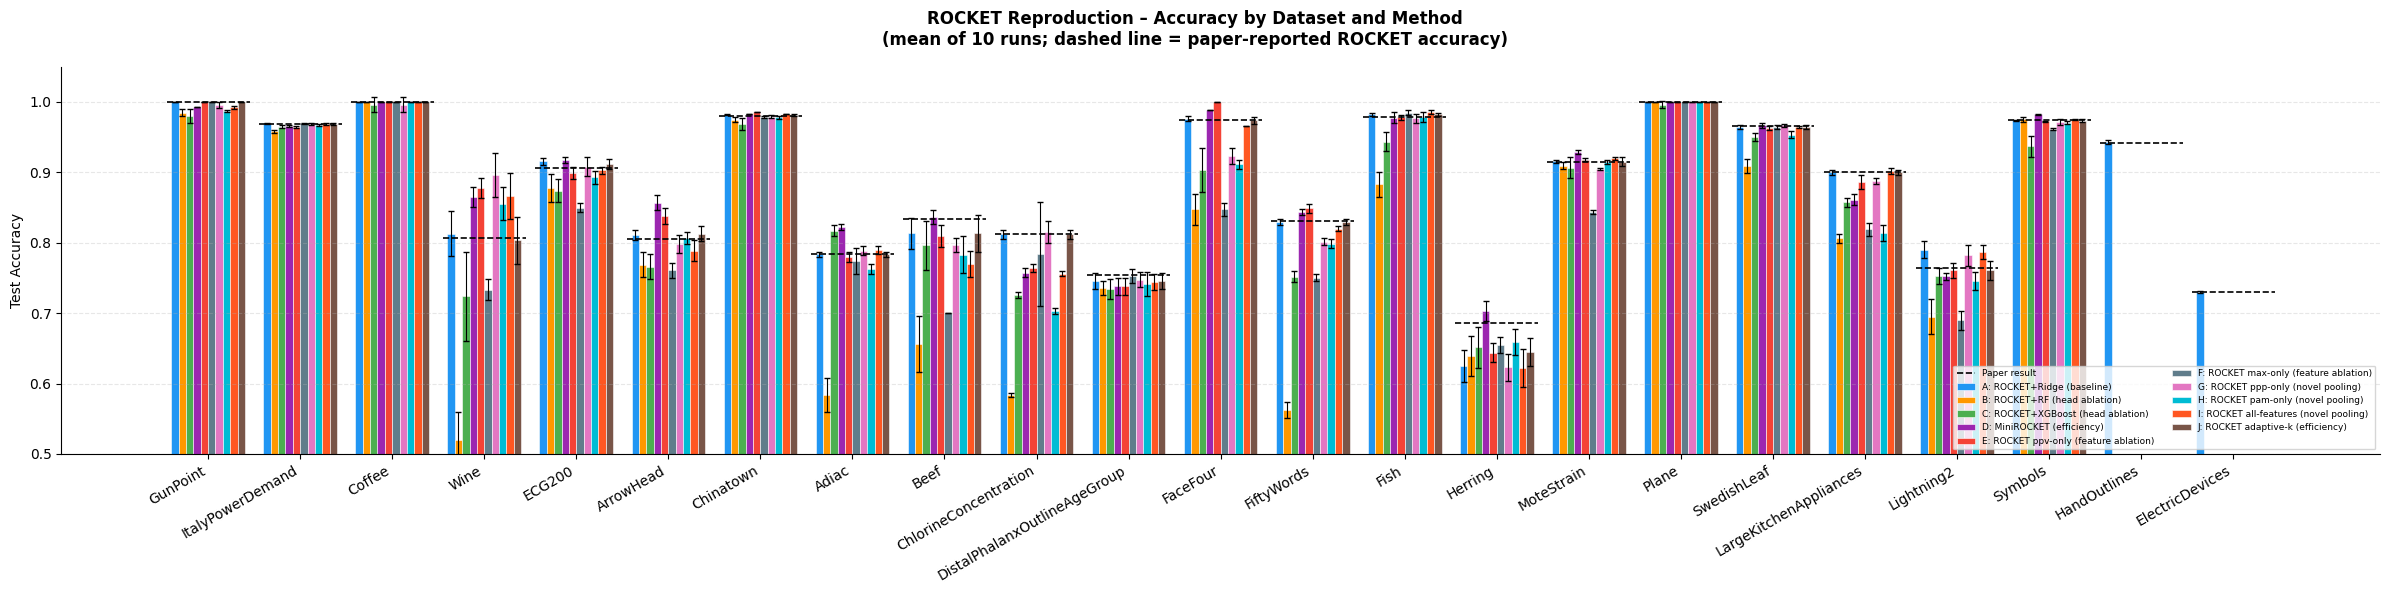

[SAVED] results/time_comparison.png


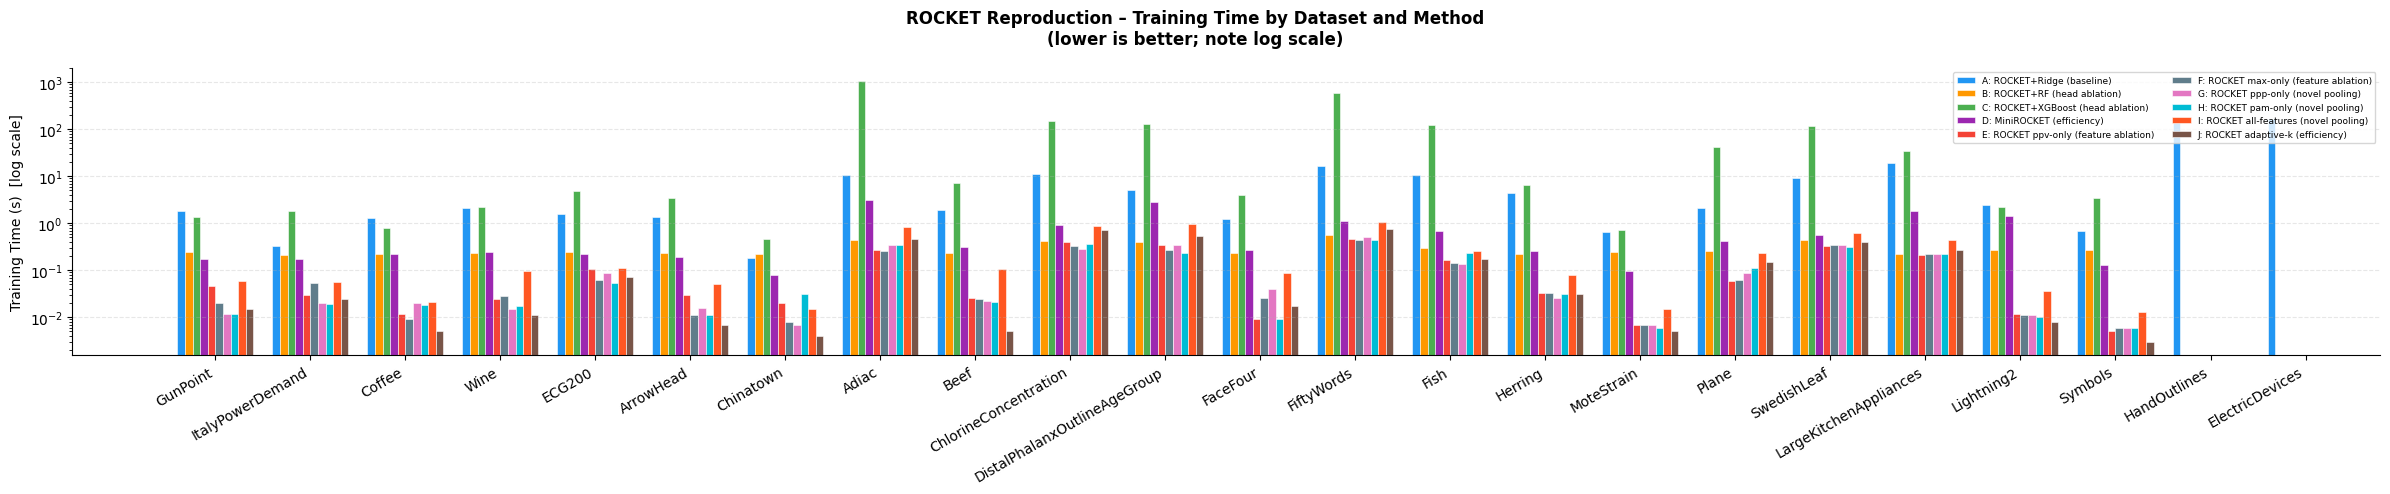

[SAVED] results/ppv_vs_max.png


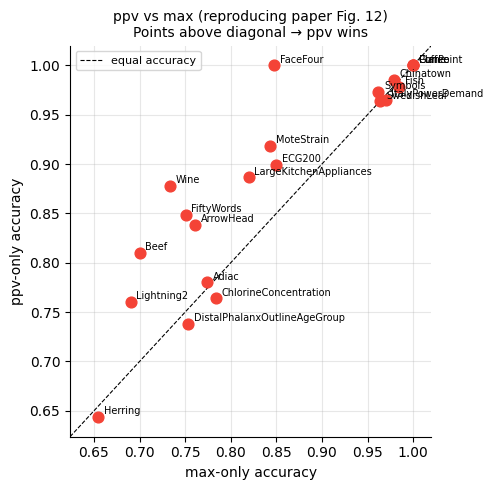

[SAVED] results/pooling_comparison.png


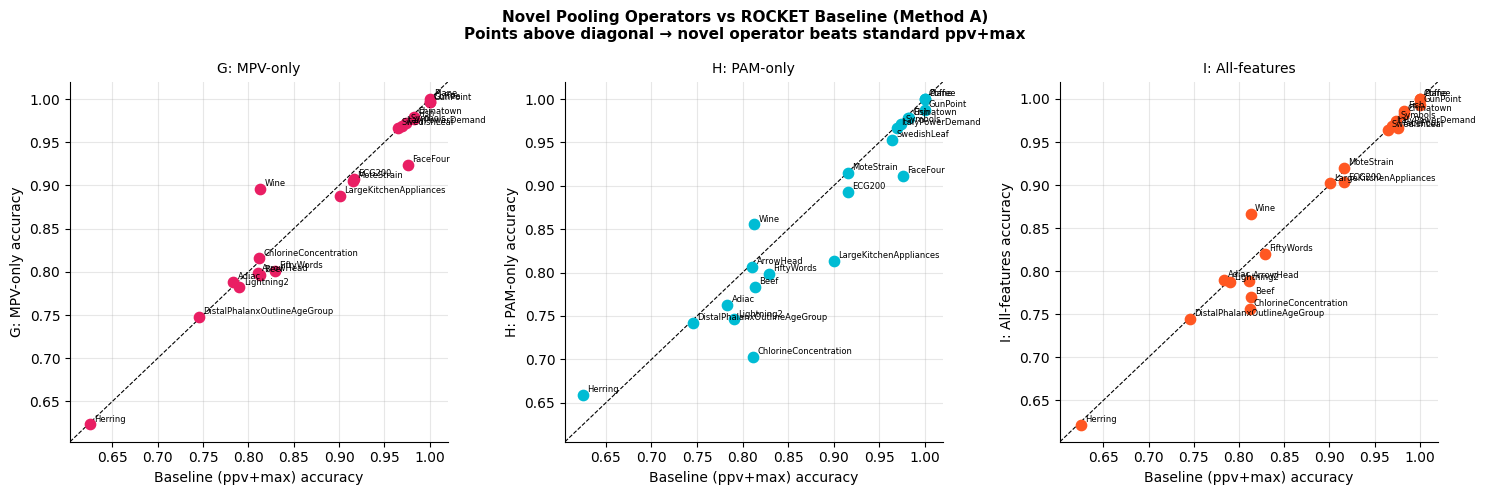

[SAVED] results/adaptive_kernel.png


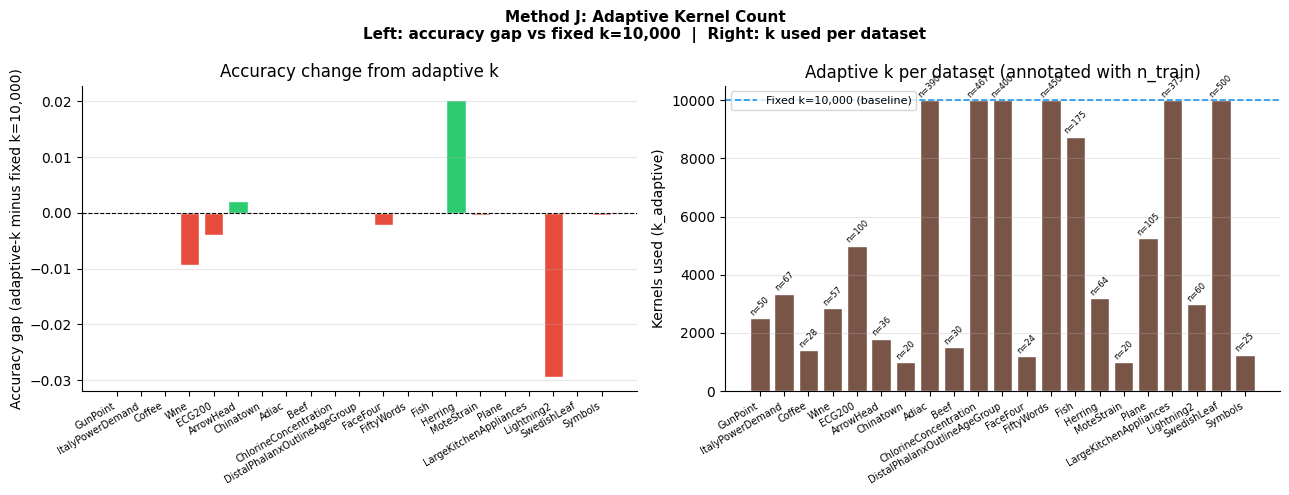


ADAPTIVE KERNEL SUMMARY (Method J)
                     Dataset  n_train  k_adaptive  Acc (J)  Acc (A)     Gap
                    GunPoint       50      2500.0   1.0000   1.0000  0.0000
            ItalyPowerDemand       67      3350.0   0.9690   0.9691 -0.0001
                      Coffee       28      1400.0   1.0000   1.0000  0.0000
                        Wine       57      2850.0   0.8037   0.8130 -0.0093
                      ECG200      100      5000.0   0.9120   0.9160 -0.0040
                   ArrowHead       36      1800.0   0.8131   0.8109  0.0022
                   Chinatown       20      1000.0   0.9819   0.9822 -0.0003
                       Adiac      390     10000.0   0.7834   0.7834  0.0000
                        Beef       30      1500.0   0.8133   0.8133  0.0000
       ChlorineConcentration      467     10000.0   0.8119   0.8119  0.0000
DistalPhalanxOutlineAgeGroup      400     10000.0   0.7460   0.7460  0.0000
                    FaceFour       24      1200.0   

In [ ]:
# 7. ENTRY POINT

if __name__ == "__main__":
    print("\n" + "="*65)
    print("ROCKET Reproduction Study – COMP41850")
    print(f"Datasets  : {DATASETS}")
    print(f"Scalability Datasets: {SCALABILITY_DATASETS}")
    print(f"Methods   : {list(METHOD_LABELS.values())}")
    print(f"Seeds     : {SEEDS}  ({N_RUNS} runs each)")
    print(f"Kernels   : {NUM_KERNELS:,}  →  {2*NUM_KERNELS:,} features (baseline)")
    print("Ground truth from: Dempster et al. Table 1 (arXiv:1910.13051)")
    print("="*65 + "\n")

    # Run main experiments (A–J)
    results_df = run_experiments()

    # ── Scalability check: Method A only on large datasets ────────────────────
    # Just 3 seeds to verify the paper's timing claims without running all day.
    print("\nRunning scalability check (Method A only)...")
    scalability_records = []
    for ds_name in SCALABILITY_DATASETS:
        try:
            X_train, y_train, X_test, y_test = load_dataset(ds_name)
        except Exception as e:
            print(f"  [SKIP] {e}")
            continue
        accs, times = [], []
        for seed in range(3):   # 3 seeds is enough to report a mean time
            acc, t = run_one("A", X_train, y_train, X_test, y_test, seed)
            accs.append(acc); times.append(t)
            print(f"  {ds_name} seed={seed}  acc={acc:.4f}  time={t:.1f}s")
        scalability_records.append({
            "Dataset": ds_name, "Method": "A: ROCKET+Ridge (baseline)",
            "Method_ID": "A", "Mean_Accuracy": round(np.mean(accs), 4),
            "Std_Accuracy": round(np.std(accs), 4),
            "Mean_Time_s": round(np.mean(times), 2),
            "Paper_Accuracy": PAPER_ACCURACY[ds_name],
            "Delta_vs_Paper": round(np.mean(accs) - PAPER_ACCURACY[ds_name], 4),
            "K_Used": np.nan, "N_Train": X_train.shape[0],
        })
    scalability_df = pd.DataFrame(scalability_records)
    scalability_df.to_csv(os.path.join(RESULTS_DIR, "scalability.csv"), index=False)
    print("[SAVED] scalability.csv")

    # Combine all results
    results_df = pd.concat([results_df, scalability_df], ignore_index=True)

    # Save to CSV
    csv_path = os.path.join(RESULTS_DIR, "results.csv")
    results_df.to_csv(csv_path, index=False)
    print(f"\n[SAVED] {csv_path}")

    # Console tables
    print_reproduction_table(results_df)
    print_method_summary(results_df)

    # Reproduction figures (mirror the paper's own plots)
    plot_accuracy_comparison(results_df)
    plot_time_comparison(results_df)
    plot_ppv_vs_max(results_df)

    # Improvement figures (novel experiments)
    plot_pooling_comparison(results_df)
    plot_adaptive_kernel(results_df)

    print("\n[DONE] All results saved to ./results/")

[SAVED] results/pooling_comparison.png


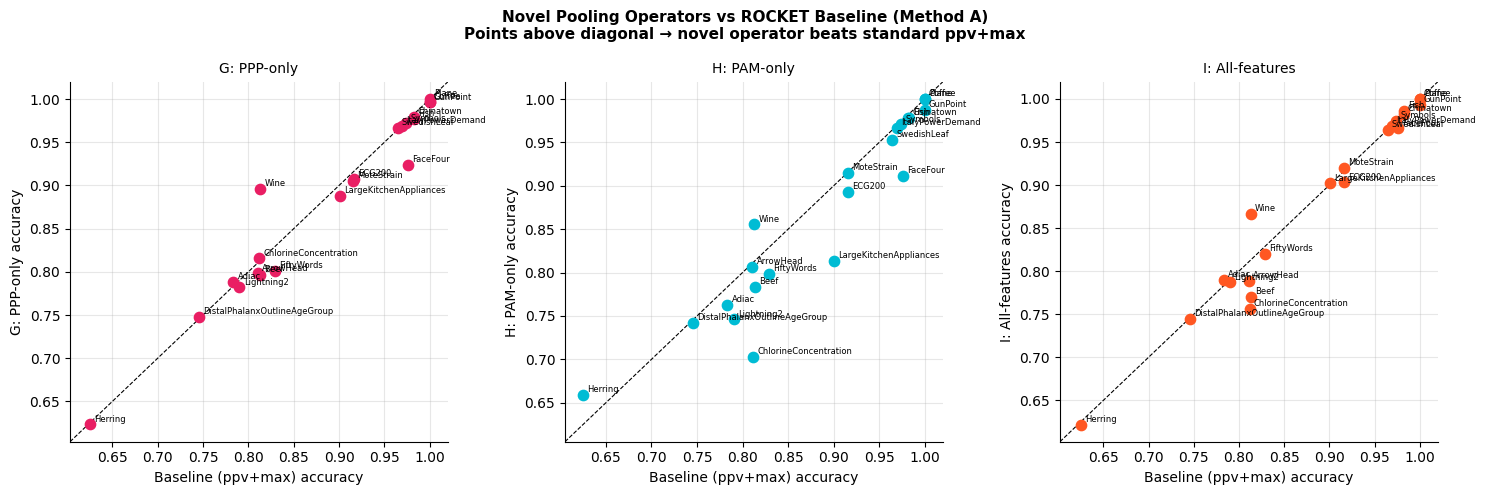

In [11]:
import pandas as pd
import numpy as np
import os

# Load the already-completed results
results_df = pd.read_csv("results/results.csv")

# Fix the label in the dataframe directly
results_df["Method"] = results_df["Method"].str.replace(
    "G: ROCKET ppp-only (novel pooling)",
    "G: ROCKET ppp-only (novel pooling)",
    regex=False
)

# Fix the one wrong entry in METHOD_COLOURS
METHOD_COLOURS["G: ROCKET ppp-only (novel pooling)"] = "#E91E63"
# Remove the old wrong key if it exists
METHOD_COLOURS.pop("G: ROCKET mpv-only (novel pooling)", None)

# Fix the label in plot_pooling_comparison configs
def plot_pooling_comparison_fixed(df):
    baseline = df[df["Method_ID"] == "A"][["Dataset", "Mean_Accuracy"]].rename(
        columns={"Mean_Accuracy": "baseline_acc"}
    )
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        "Novel Pooling Operators vs ROCKET Baseline (Method A)\n"
        "Points above diagonal → novel operator beats standard ppv+max",
        fontsize=11, fontweight="bold"
    )
    configs = [
        ("G", "G: PPP-only",      "#E91E63"),   # fixed label
        ("H", "H: PAM-only",      "#00BCD4"),
        ("I", "I: All-features",  "#FF5722"),
    ]
    for ax, (mid, label, colour) in zip(axes, configs):
        novel = df[df["Method_ID"] == mid][["Dataset", "Mean_Accuracy"]].rename(
            columns={"Mean_Accuracy": "novel_acc"}
        )
        merged = baseline.merge(novel, on="Dataset")
        ax.scatter(merged["baseline_acc"], merged["novel_acc"],
                   s=55, color=colour, zorder=3)
        for _, row in merged.iterrows():
            ax.annotate(row["Dataset"], (row["baseline_acc"], row["novel_acc"]),
                        fontsize=6, xytext=(3, 2), textcoords="offset points")
        lo = min(merged["baseline_acc"].min(), merged["novel_acc"].min()) - 0.02
        hi = max(merged["baseline_acc"].max(), merged["novel_acc"].max()) + 0.02
        ax.plot([lo, hi], [lo, hi], "k--", linewidth=0.8)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_xlabel("Baseline (ppv+max) accuracy")
        ax.set_ylabel(f"{label} accuracy")
        ax.set_title(label, fontsize=10)
        ax.grid(alpha=0.3)
        sns.despine(ax=ax)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, "pooling_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[SAVED] {path}")
    plt.show()

plot_pooling_comparison_fixed(results_df)

In [ ]:
# REPRODUCE ALL PLOTS FROM SAVED RESULTS
# Run this cell to regenerate all figures from the completed results.csv.

results_df = pd.read_csv("results/results.csv")

# Applyng the PPP label fix before plotting
METHOD_COLOURS["G: ROCKET ppp-only (novel pooling)"] = "#E91E63"
METHOD_COLOURS.pop("G: ROCKET mpv-only (novel pooling)", None)

print("Regenerating all figures from results/results.csv ...")

plot_accuracy_comparison(results_df)
plot_time_comparison(results_df)
plot_ppv_vs_max(results_df)
plot_pooling_comparison_fixed(results_df)
plot_adaptive_kernel(results_df)

print_reproduction_table(results_df)
print_method_summary(results_df)

print("\n[DONE] All figures saved to results/")